# Estimation of R
Rを求めて海表面情報を探索する試み。

In [1]:
# 依存パッケージをimport

import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pywt

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.gnssir_cl import gnssir

#@formatter:off
%matplotlib inline

## RINEX → SNR

下記ディレクトリにRINEXファイルを入れる。

refl_code/yyyy/rinex/TTTT/TTTTXXX0.yyo
- yyyy：西暦
- TTTT：局名。アルファベット4文字。
- XXX：day of year
- yy：西暦下二桁

In [4]:
year = 2020
doy = 277
doy_end = 288
station = "calc"

rinex2snr(station, year, doy, doy_end=doy_end, nolook=True)

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr value of  66
Using default orbit for this time period:  nav
Using archive value of  all
Station  calc  has four characters, assume RINEX 2.11 format
No parallel processing
SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr66 

SNR file already e

## SNRファイルの読み込み

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# SNR ファイルのカラム名（マニュアル準拠）
SNR_COLUMNS_FULL = [
    "sat",              # 衛星番号
    "elev_deg",         # 仰角 [deg]
    "az_deg",           # 方位角 [deg]
    "sec_of_day",       # 秒（GPS time）
    "edot_deg_per_s",   # 仰角変化率 [deg/s]
    "snr_L6",           # S6 (L6) SNR [dB-Hz]
    "snr_L1",           # S1 (L1)
    "snr_L2",           # S2 (L2)
    "snr_L5",           # S5 (L5)
    "snr_L7",           # S7 (L7)
    "snr_L8",           # S8 (L8)
]


def read_snr_file_gz(path: Path) -> pd.DataFrame:
    """1つの .snr*.gz ファイルを読み込んで DataFrame を返す。"""
    df = pd.read_csv(
        path,
        sep=r"\s+",        # ← FutureWarning 回避
        header=None,
        comment="#",
        compression="gzip",
        engine="python",
    )
    n_cols = df.shape[1]
    df.columns = SNR_COLUMNS_FULL[:n_cols]
    return df


def load_snr_directory(year: int, station: str,
                       base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    /etc/gnssrefl/refl_code/{year}/snr/{station}/ 配下の
    .snr*.gz ファイルだけを全部読み込んで

    - snr_dict: {ファイル名: DataFrame}
    - snr_table: 全ファイルを縦結合した DataFrame
                 (year, station, doy, file などの情報付き)

    を返す。
    """
    snr_dir = Path(base_dir) / str(year) / "snr" / station

    if not snr_dir.is_dir():
        raise FileNotFoundError(f"ディレクトリが見つかりません: {snr_dir}")

    snr_files = sorted(snr_dir.glob("*.snr*.gz"))

    if not snr_files:
        print(f"*.snr*.gz が見つかりません: {snr_dir}")

    snr_dict = {}
    table_list = []

    for f in snr_files:
        df = read_snr_file_gz(f)
        snr_dict[f.name] = df

        # ファイル名から DOY を推定（例: calc2770.20.snr66.gz）
        name_no_gz = f.name[:-3] if f.name.endswith(".snr88.gz") else f.name
        stem = name_no_gz.split(".")[0]   # "calc2770"
        doy = int(stem[len(station):len(station) + 3])  # "277"

        df2 = df.copy()
        df2["year"] = year
        df2["station"] = station
        df2["file"] = f.name
        df2["doy"] = doy
        table_list.append(df2)

    if table_list:
        snr_table = pd.concat(table_list, ignore_index=True)
    else:
        snr_table = pd.DataFrame()

    return snr_dict, snr_table

def main(year: int,
         station: str,
         snr_dict_existing=None,
         base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    - Jupyter で既に snr_dict を作っているなら snr_dict_existing を渡す
    - そうでなければディレクトリから読み込む

    戻り値:
        snr_dict, snr_table
    """
    if snr_dict_existing is None:
        snr_dict, snr_table = load_snr_directory(year, station, base_dir=base_dir)
    else:
        # 既存の snr_dict から snr_table だけ再構成したい場合など
        snr_dict = snr_dict_existing
        # ここで snr_table を組み立て直すなら、上の build 処理を使い回すイメージ
        # 必要なら別関数に分けてもよい
        rows = []
        for fname, df in snr_dict.items():
            name_no_gz = fname[:-3] if fname.endswith(".gz") else fname
            stem = name_no_gz.split(".")[0]
            doy = int(stem[len(station):len(station) + 3])

            tmp = df.copy()
            tmp["year"] = year
            tmp["station"] = station
            tmp["file"] = fname
            tmp["doy"] = doy
            rows.append(tmp)
        snr_table = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    return snr_dict, snr_table


## コヒーレント・インコヒーレント比率を求める

### Plot用

In [85]:
import matplotlib.pyplot as plt

def plot_R_e(e: np.ndarray, R: np.ndarray, title: str | None = None):
    plt.figure()
    plt.plot(e, R)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    plt.figure()
    R_dB = 10 * np.log10(R)
    plt.plot(e, R_dB)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh [dB]")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    


def plot_wavelet_power_e_h(e_grid, h_grid, P, title=None):
    import numpy as np
    import matplotlib.pyplot as plt

    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P, float)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(
            f"P.shape={P.shape}, expected ({len(e_grid)}, {len(h_grid)})"
        )

    # 0 以上に限定
    P[P < 0] = 0.0
    Pmax = np.nanmax(P)
    if not np.isfinite(Pmax) or Pmax <= 0:
        Pmax = 1.0  # 全部ゼロだったときの保険

    E, H = np.meshgrid(e_grid, h_grid, indexing="xy")

    plt.figure()
    pcm = plt.pcolormesh(E, H, P.T, shading="auto", vmin=0.0, vmax=Pmax)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("Height h [m]")
    if title is not None:
        plt.title(title)
    cb = plt.colorbar(pcm)
    cb.set_label(r"$|W(e,h)|^2$")
    plt.tight_layout()
    plt.show()



読み込み完了
sat=1 (up): T_best=0.354 m, sigma_h=0.030 m, alpha=55.921, beta=0.386, az=308.8 deg, points=218, sse=0.0266


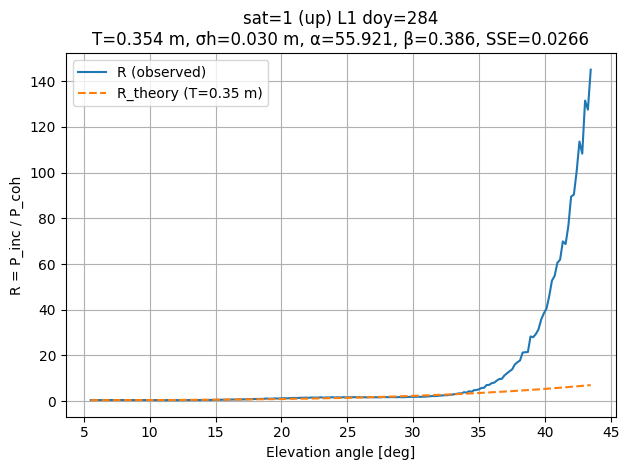

sat=1 (down): T_best=0.101 m, sigma_h=0.030 m, alpha=165.264, beta=0.970, az=258.7 deg, points=328, sse=0.512


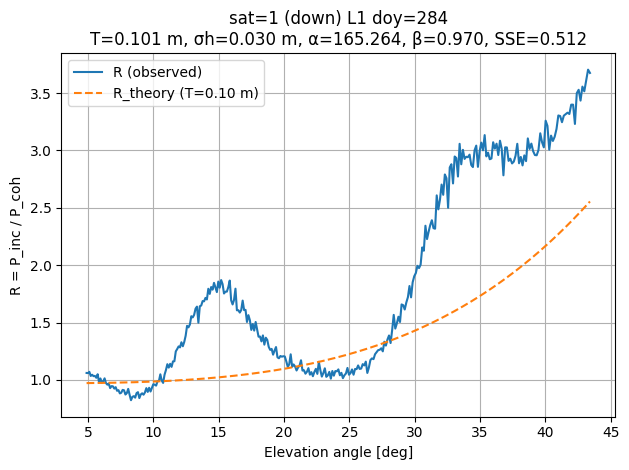

sat=2 (up): データなし → スキップ
sat=2 (down): T フィット失敗 → スキップ
sat=3 (up): T_best=0.025 m, sigma_h=0.030 m, alpha=5755.763, beta=0.647, az=308.4 deg, points=322, sse=0.0498


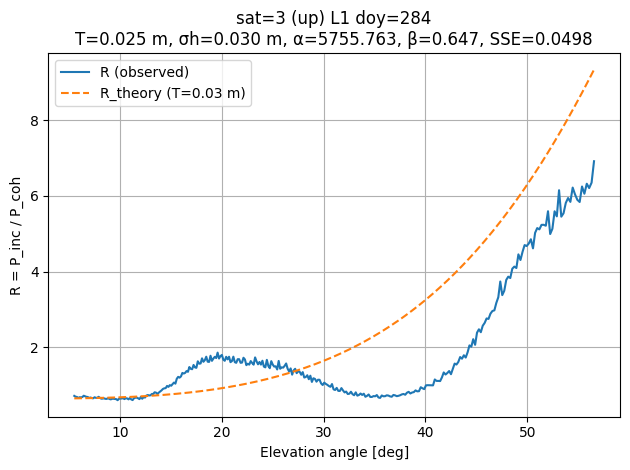

sat=3 (down): T フィット失敗 → スキップ
sat=4 (up): T_best=0.127 m, sigma_h=0.030 m, alpha=1949.183, beta=0.339, az=319.2 deg, points=452, sse=0.0106


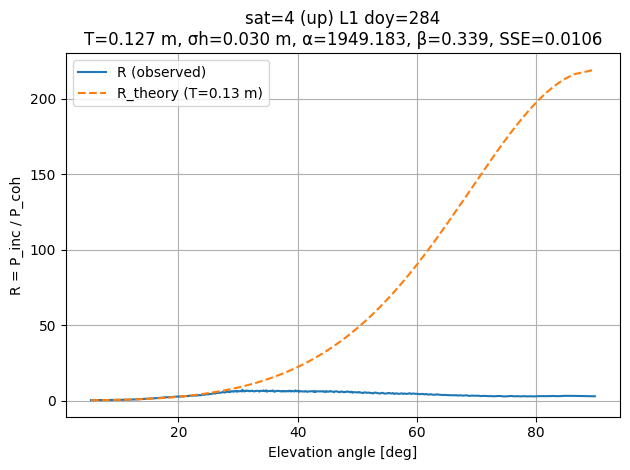

sat=4 (down): 有効点が少なすぎる (1点) → スキップ
sat=5 (up): データなし → スキップ
sat=5 (down): T_best=0.076 m, sigma_h=0.030 m, alpha=968.475, beta=0.336, az=44.1 deg, points=411, sse=0.168


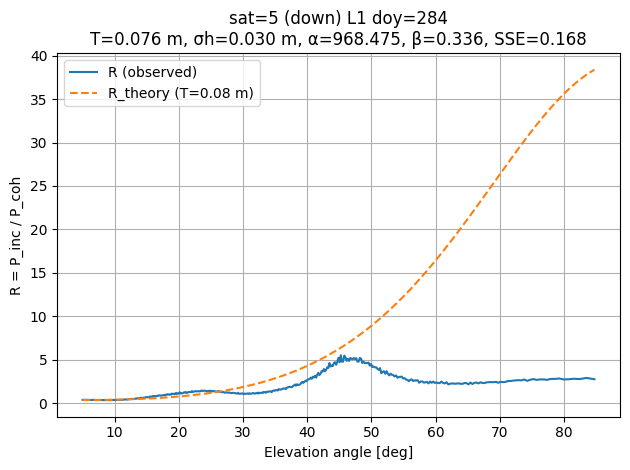

sat=6 (up): データなし → スキップ
sat=6 (down): T_best=0.937 m, sigma_h=0.030 m, alpha=0.265, beta=0.302, az=63.8 deg, points=71, sse=0.0911


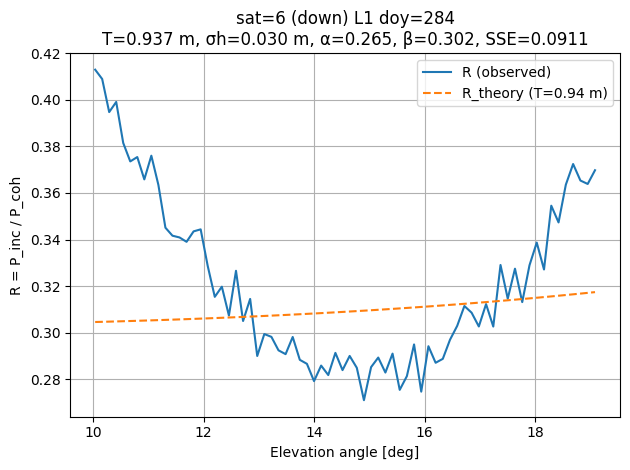

sat=7 (up): T_best=1.620 m, sigma_h=0.030 m, alpha=5.720, beta=0.615, az=318.6 deg, points=520, sse=0.0442


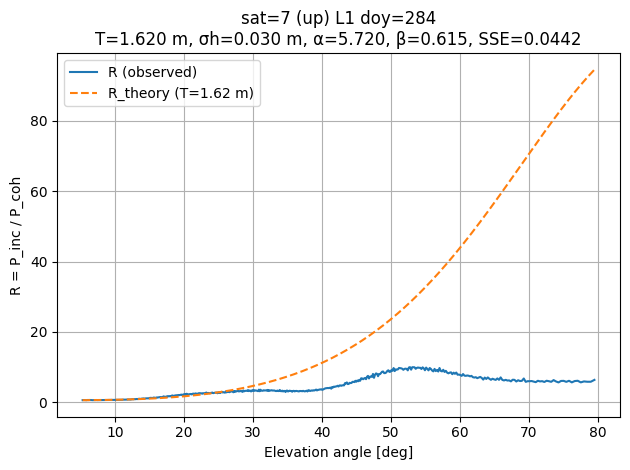

sat=7 (down): 有効点が少なすぎる (2点) → スキップ
sat=8 (up): T_best=1.570 m, sigma_h=0.030 m, alpha=3.872, beta=0.383, az=308.6 deg, points=105, sse=0.0103


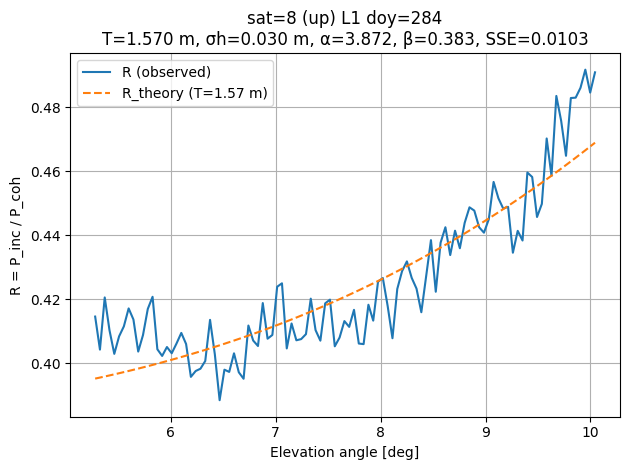

sat=8 (down): T_best=0.557 m, sigma_h=0.030 m, alpha=21.694, beta=0.442, az=24.4 deg, points=427, sse=0.381


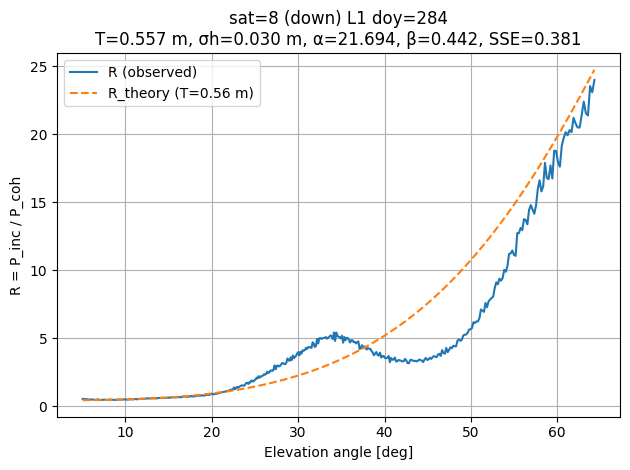

sat=9 (up): T_best=0.430 m, sigma_h=0.030 m, alpha=107.397, beta=0.527, az=309.3 deg, points=359, sse=0.0616


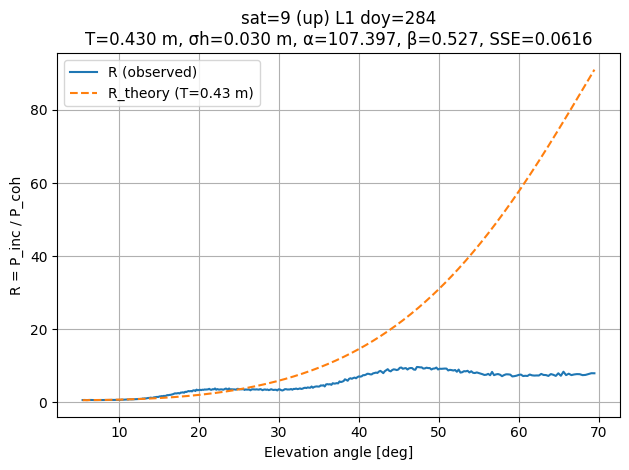

sat=9 (down): T フィット失敗 → スキップ
sat=10 (up): T_best=1.696 m, sigma_h=0.030 m, alpha=0.759, beta=0.214, az=309.0 deg, points=561, sse=0.0548


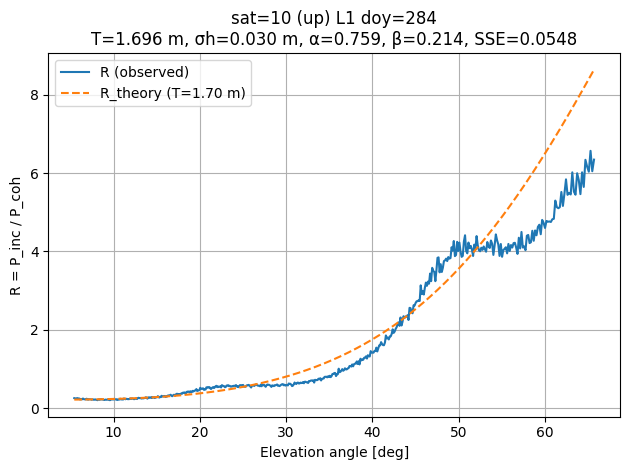

sat=10 (down): T フィット失敗 → スキップ
sat=11 (up): T_best=1.924 m, sigma_h=0.030 m, alpha=6.283, beta=0.465, az=303.8 deg, points=173, sse=0.0125


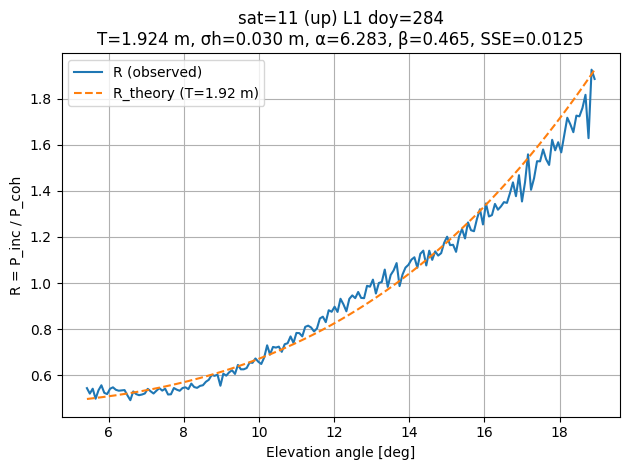

sat=11 (down): T_best=0.228 m, sigma_h=0.030 m, alpha=166.609, beta=0.172, az=335.2 deg, points=411, sse=1.13


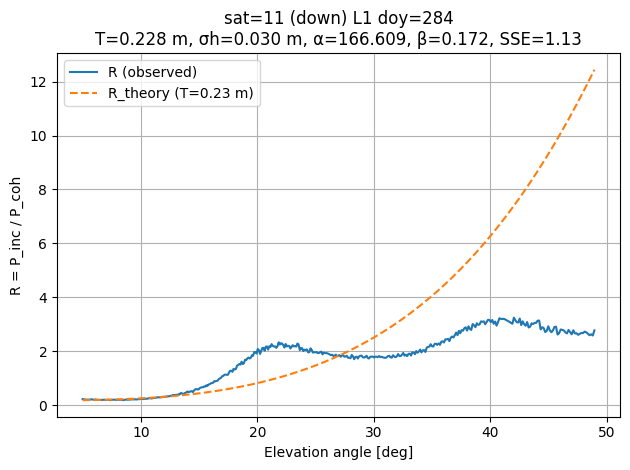

sat=12 (up): 有効点が少なすぎる (22点) → スキップ
sat=12 (down): T_best=0.532 m, sigma_h=0.030 m, alpha=178.922, beta=1.210, az=51.8 deg, points=175, sse=0.0204


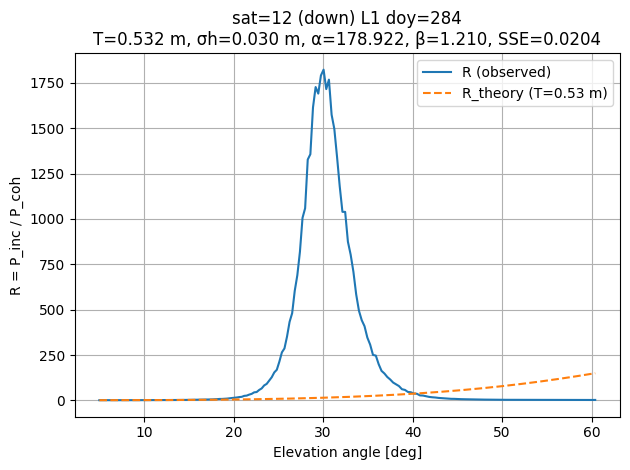

sat=13 (up): T_best=0.430 m, sigma_h=0.030 m, alpha=7.844, beta=1.327, az=308.3 deg, points=201, sse=1


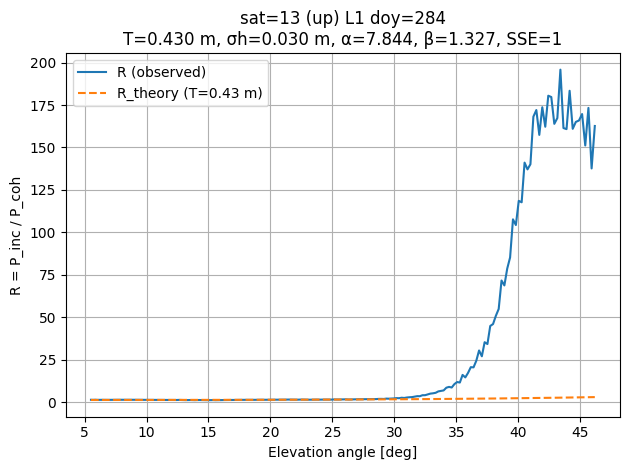

sat=13 (down): T_best=0.684 m, sigma_h=0.030 m, alpha=3.663, beta=0.738, az=33.4 deg, points=308, sse=1.38


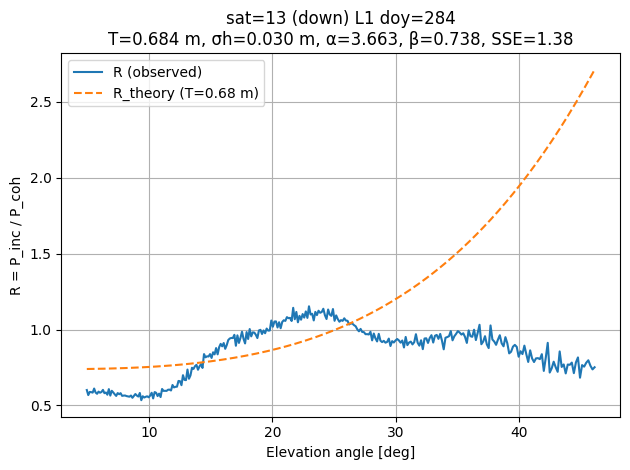

sat=14: データなし → スキップ
sat=15 (up): データなし → スキップ
sat=15 (down): T_best=0.127 m, sigma_h=0.030 m, alpha=294.286, beta=0.273, az=48.2 deg, points=330, sse=0.0939


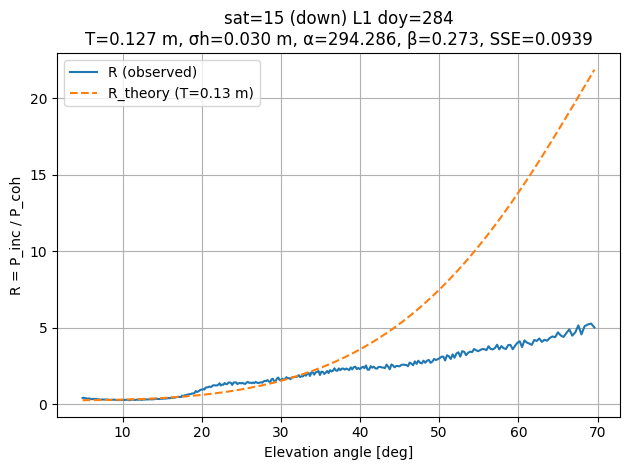

sat=16 (up): データなし → スキップ
sat=16 (down): T_best=0.051 m, sigma_h=0.030 m, alpha=3115.691, beta=0.251, az=43.5 deg, points=376, sse=0.048


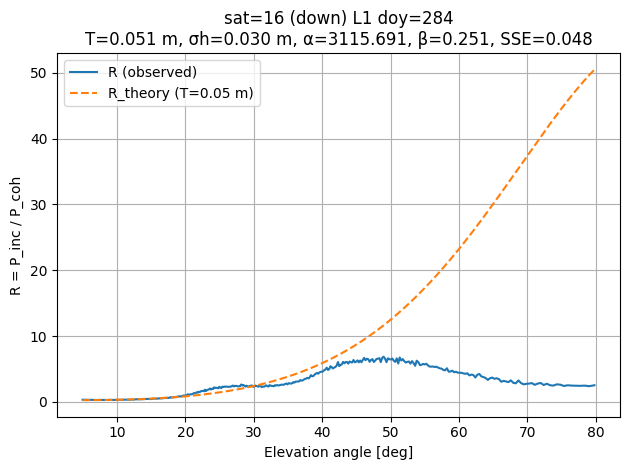

sat=17 (up): T_best=0.025 m, sigma_h=0.030 m, alpha=0.000, beta=1.833, az=242.9 deg, points=183, sse=0.254


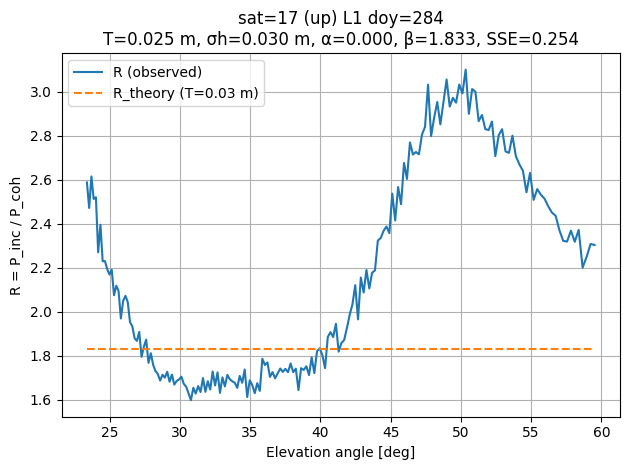

sat=17 (down): データなし → スキップ
sat=18 (up): T_best=0.127 m, sigma_h=0.030 m, alpha=141.293, beta=0.432, az=321.6 deg, points=501, sse=0.0867


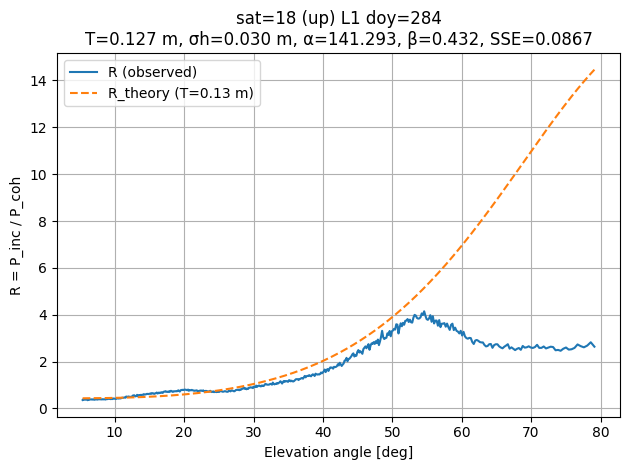

sat=18 (down): 有効点が少なすぎる (2点) → スキップ
sat=19 (up): T_best=1.823 m, sigma_h=0.030 m, alpha=0.476, beta=1.725, az=234.5 deg, points=180, sse=0.692


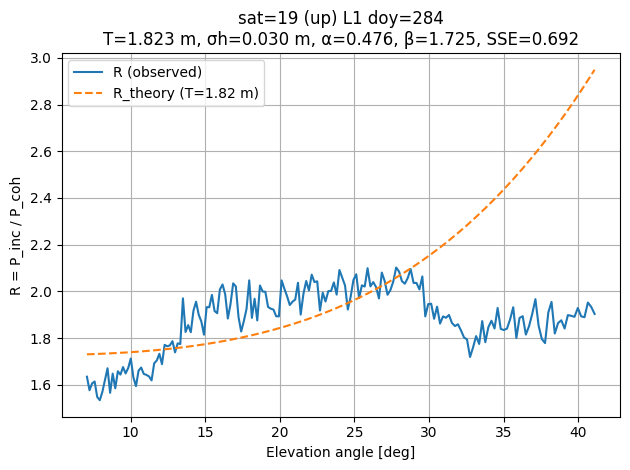

sat=19 (down): データなし → スキップ
sat=20 (up): T_best=0.481 m, sigma_h=0.030 m, alpha=14.384, beta=0.254, az=293.5 deg, points=534, sse=0.0548


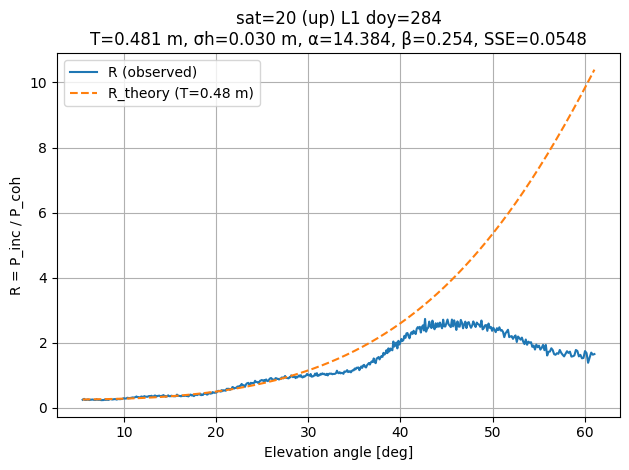

sat=20 (down): T フィット失敗 → スキップ
sat=21 (up): T_best=0.810 m, sigma_h=0.030 m, alpha=6.312, beta=0.436, az=307.5 deg, points=296, sse=0.071


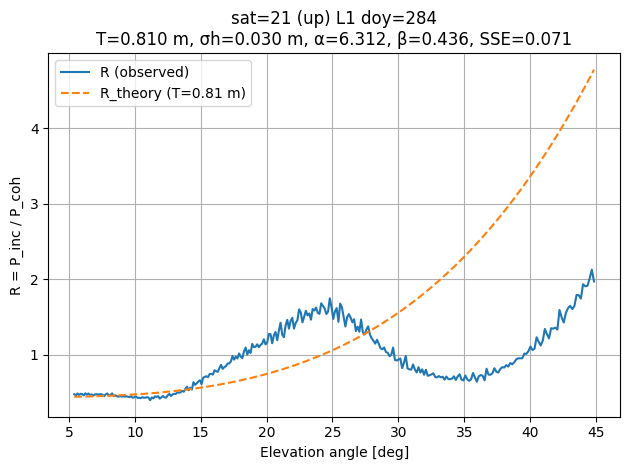

sat=21 (down): T_best=0.177 m, sigma_h=0.030 m, alpha=72.606, beta=0.322, az=308.9 deg, points=425, sse=4.49


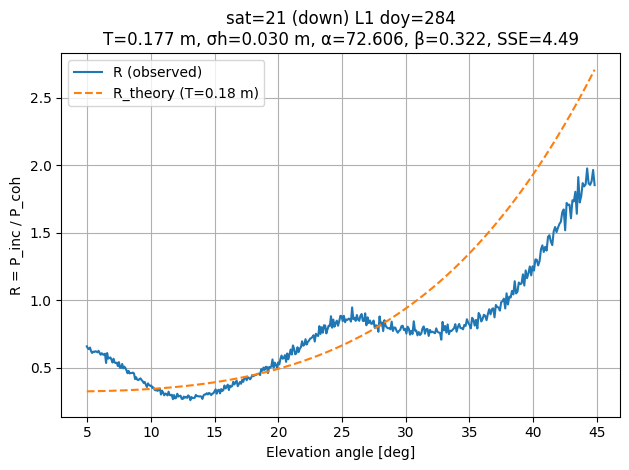

sat=22 (up): T_best=0.380 m, sigma_h=0.030 m, alpha=33.883, beta=0.459, az=306.1 deg, points=351, sse=0.0194


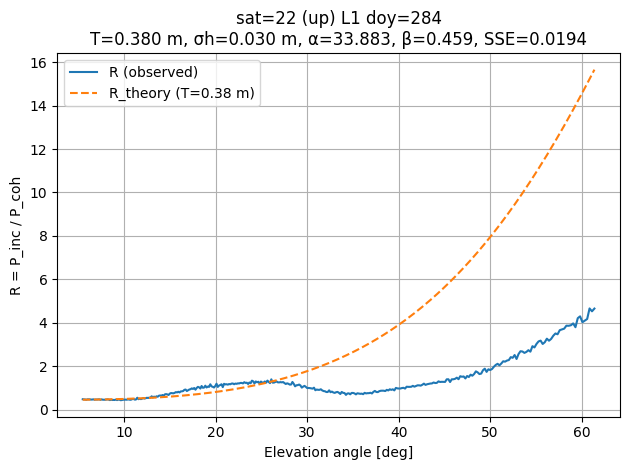

sat=22 (down): T フィット失敗 → スキップ
sat=23 (up): T_best=0.076 m, sigma_h=0.030 m, alpha=628.650, beta=0.323, az=289.1 deg, points=516, sse=0.0872


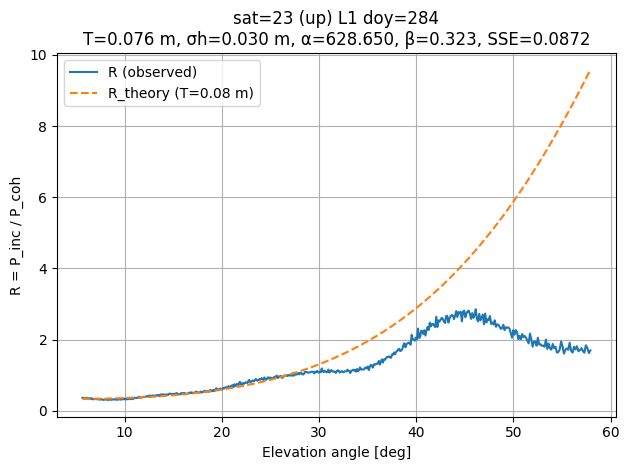

sat=23 (down): T フィット失敗 → スキップ
sat=24 (up): データなし → スキップ
sat=24 (down): T_best=0.734 m, sigma_h=0.030 m, alpha=2.179, beta=0.604, az=49.5 deg, points=224, sse=0.169


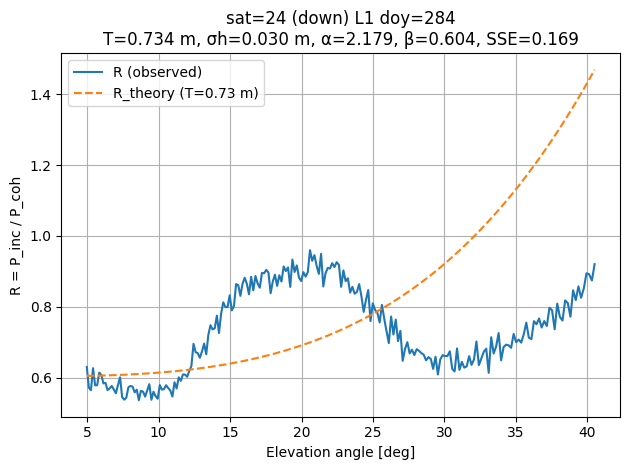

sat=25 (up): T フィット失敗 → スキップ
sat=25 (down): T_best=1.418 m, sigma_h=0.030 m, alpha=2.199, beta=0.403, az=301.6 deg, points=417, sse=0.322


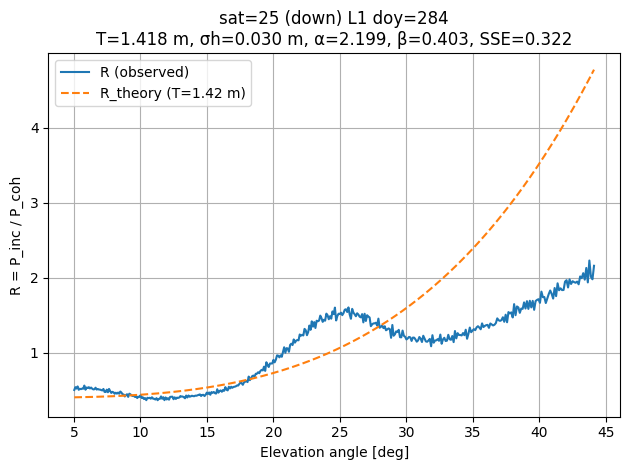

sat=26 (up): T_best=0.000 m, sigma_h=0.030 m, alpha=0.000, beta=0.415, az=305.6 deg, points=72, sse=0.00142


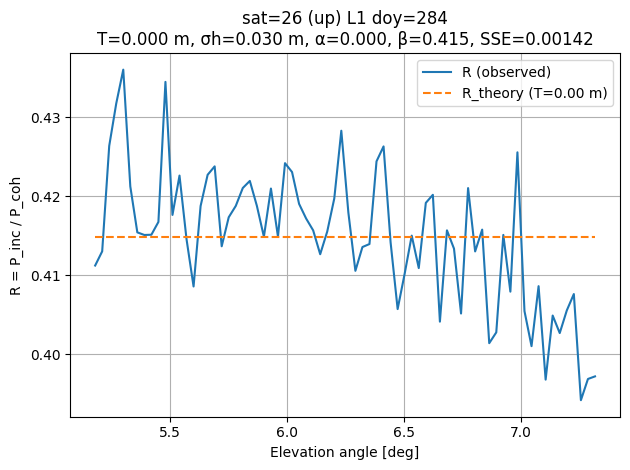

sat=26 (down): T_best=0.228 m, sigma_h=0.030 m, alpha=216.452, beta=0.591, az=33.1 deg, points=397, sse=0.289


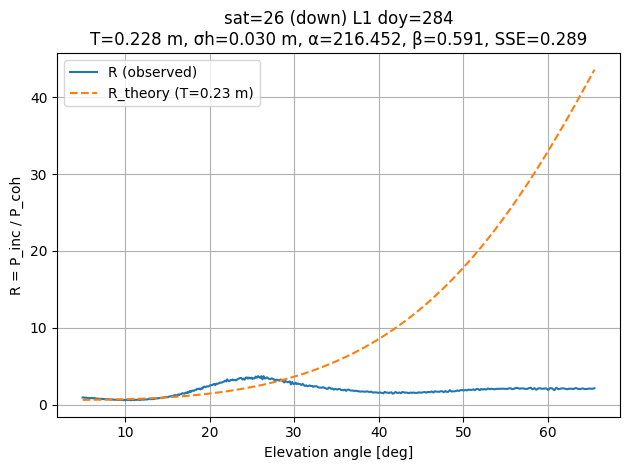

sat=27 (up): T_best=0.101 m, sigma_h=0.030 m, alpha=460.017, beta=0.206, az=308.8 deg, points=197, sse=0.0432


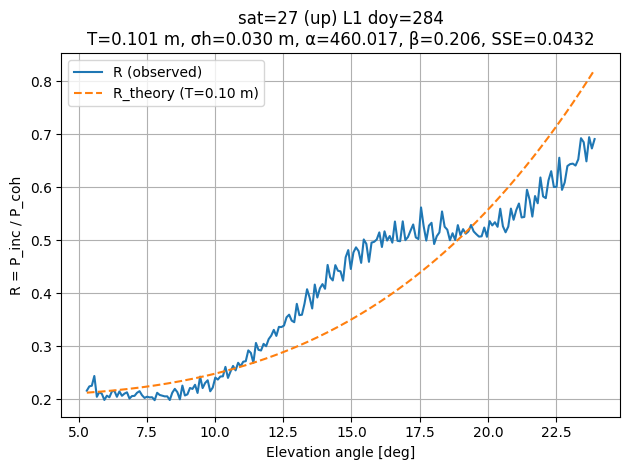

sat=27 (down): T_best=0.000 m, sigma_h=0.030 m, alpha=0.000, beta=0.756, az=343.6 deg, points=478, sse=4.38


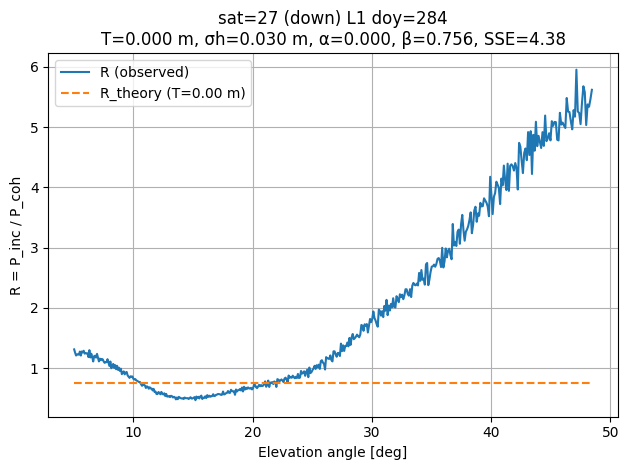

sat=28 (up): T_best=0.684 m, sigma_h=0.030 m, alpha=38.981, beta=0.323, az=292.9 deg, points=463, sse=0.694


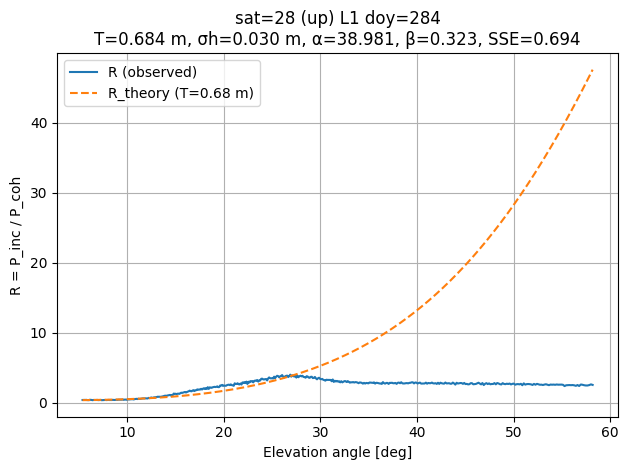

sat=28 (down): データなし → スキップ
sat=29 (up): T_best=0.278 m, sigma_h=0.030 m, alpha=16.209, beta=0.272, az=316.6 deg, points=311, sse=0.0435


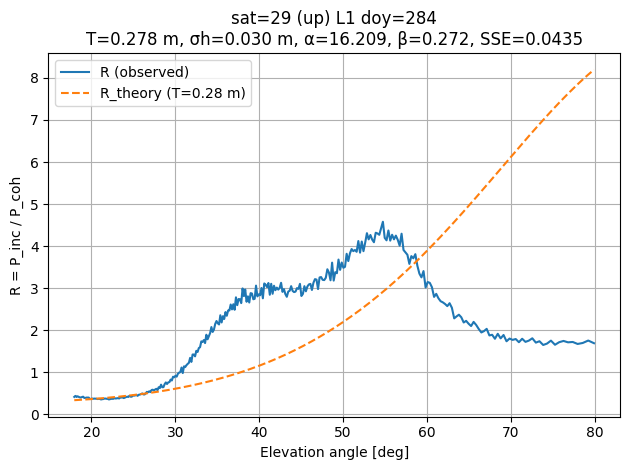

sat=29 (down): T フィット失敗 → スキップ
sat=30 (up): T_best=0.177 m, sigma_h=0.030 m, alpha=924.721, beta=0.583, az=314.4 deg, points=437, sse=0.205


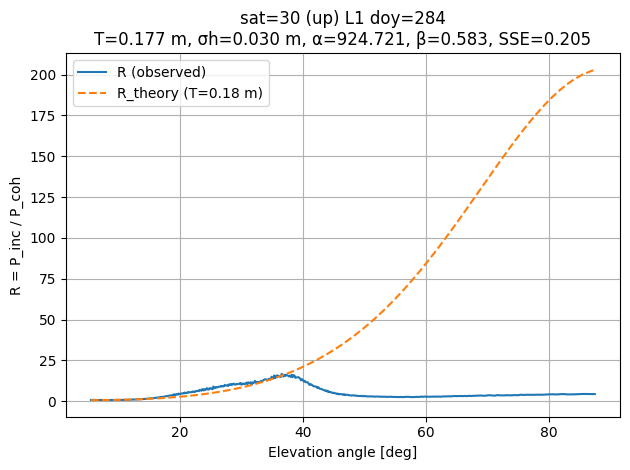

sat=30 (down): 有効点が少なすぎる (6点) → スキップ
sat=31 (up): T フィット失敗 → スキップ
sat=31 (down): T_best=1.342 m, sigma_h=0.030 m, alpha=3.258, beta=3.029, az=33.0 deg, points=424, sse=0.0477


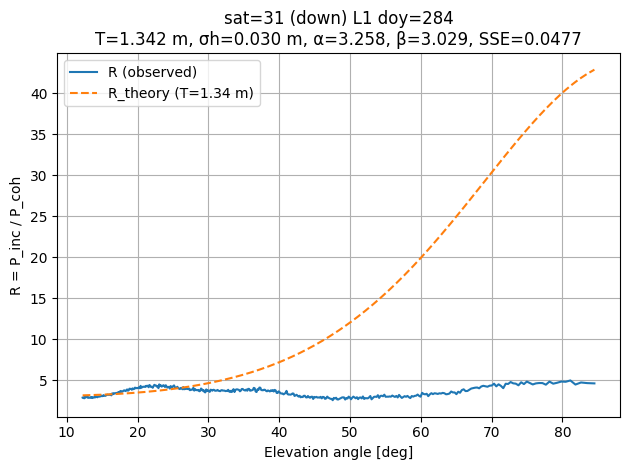

sat=32 (up): T_best=0.000 m, sigma_h=0.030 m, alpha=0.000, beta=0.829, az=258.0 deg, points=362, sse=0.00843


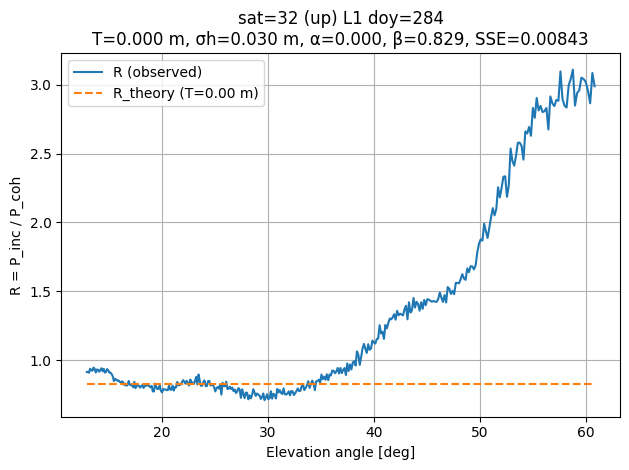

sat=32 (down): T フィット失敗 → スキップ
    sat direction  az_mean_deg  T_best_m  alpha_best  beta_best       sse  \
0     1        up   308.801500  0.354430   55.921457   0.385913  0.026560   
5     6      down    63.836339  0.936709    0.264985   0.302435  0.091087   
6     7        up   318.565641  1.620253    5.720331   0.614745  0.044201   
7     8        up   308.573261  1.569620    3.872385   0.382906  0.010264   
8     8      down    24.376084  0.556962   21.694086   0.441984  0.380553   
9     9        up   309.341052  0.430380  107.396856   0.526896  0.061573   
10   10        up   308.992221  1.696203    0.758709   0.214099  0.054760   
11   11        up   303.836216  1.924051    6.283022   0.465213  0.012516   
12   11      down   335.181679  0.227848  166.609151   0.172089  1.127781   
13   12      down    51.754790  0.531646  178.922464   1.210302  0.020352   
14   13        up   308.254052  0.430380    7.844370   1.327400  1.001682   
15   13      down    33.422927  0.683544    3

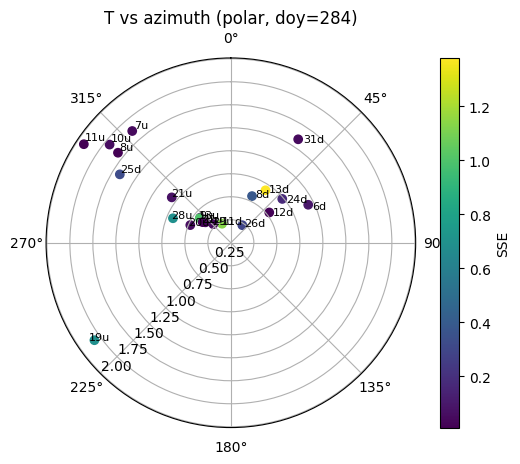

結果を T_fit_sat1_32_doy284.csv に保存しました。


In [20]:
LAMBDA_L1 = 0.190293672798365  # [m] GNSS L1 の波長

def compute_R_theory_BS(
    e_deg: np.ndarray,
    h0: float,
    sigma_h: float,
    T: float,
    wavelength_m: float = LAMBDA_L1,
    m_max: int = 50,
    alpha: float = 1.0,
    beta: float = 0.0,
) -> np.ndarray:
    """
    Beckmann–Spizzichino model による理論 R(e) を計算し，
    最後に R_cal(e) = alpha * R_BS(e) + beta を適用する。

    e_deg   : 仰角 [deg]（配列）
    h0      : 反射高 [m]
    sigma_h : 表面の RMS 高さ [m]
    T       : 相関長 [m]
    wavelength_m : 波長 [m]
    m_max   : 級数和の打ち切り次数
    alpha   : スケール係数
    beta    : オフセット
    """
    e_deg = np.asarray(e_deg, float)
    e_rad = np.deg2rad(e_deg)
    sin_e = np.sin(e_rad)

    # 結果用配列（とりあえず NaN）
    R_theory = np.full_like(e_rad, np.nan, dtype=float)

    # sin(e)=0 だと式が崩れるのでマスク
    mask = sin_e > 0
    if not np.any(mask):
        return R_theory

    sin_e_m = sin_e[mask]

    # g(e) = (4π σ_h sin(e) / λ)^2
    g = (4.0 * np.pi * sigma_h * sin_e_m / wavelength_m) ** 2

    # A(e) ≈ π λ h0 / sin(e)
    A = np.pi * wavelength_m * h0 / sin_e_m

    # Σ_{m=1}^∞ g^m / (m! m) を数値的に計算
    S = np.zeros_like(g)
    term = g.copy()  # これが g^1 / 1! に対応

    for m in range(1, m_max + 1):
        S += term / m          # += g^m / (m! * m)
        term = term * g / (m + 1)  # term ← g^{m+1} / (m+1)!

    # 素の BS 理論
    R_bs = (np.pi * T**2 / A) * S

    # alpha・beta を適用
    R_theory[mask] = alpha * R_bs + beta

    return R_theory


def detrend_snr_gnss_ir(x, y, poly_order: int = 2):
    coef = np.polyfit(x, y, poly_order)
    trend = np.polyval(coef, x)
    return y - trend, trend


def compute_wavelet_power_e_h(
    elev_deg: np.ndarray,
    snr_series: np.ndarray,
    h_grid: np.ndarray,
    wavelength_m: float = LAMBDA_L1,
    wavelet_name: str = "cmor10.0-5.0",
):
    elev_deg = np.asarray(elev_deg, float)
    snr_series = np.asarray(snr_series, float)
    h_grid = np.asarray(h_grid, float)

    # 1) x = sin(e)
    x = np.sin(np.deg2rad(elev_deg))
    order = np.argsort(x)
    x = x[order]
    y = snr_series[order]

    # 2) 等間隔 x グリッド
    N = len(x)
    x_uniform = np.linspace(x[0], x[-1], N)
    y_uniform = np.interp(x_uniform, x, y)

    # 3) トレンド除去
    y_detr, trend = detrend_snr_gnss_ir(x_uniform, y_uniform, poly_order=2)

    # 4) CWT 準備
    dt = x_uniform[1] - x_uniform[0]
    wavelet = pywt.ContinuousWavelet(wavelet_name)
    f_c = pywt.central_frequency(wavelet)

    # 5) h_grid -> scale
    #   f_x = 2h / λ
    #   scale = f_c / (f_x * dt) = λ f_c / (2 h dt)
    scales = np.zeros_like(h_grid, dtype=float)
    valid = h_grid > 0

    f_x = np.zeros_like(h_grid, dtype=float)
    f_x[valid] = 2.0 * h_grid[valid] / wavelength_m
    scales[valid] = f_c / (f_x[valid] * dt)  # = λ f_c / (2 h dt)

    valid_idx = np.where(valid & np.isfinite(scales) & (scales > 0))[0]
    scales_valid = scales[valid_idx]
    if len(scales_valid) == 0:
        raise ValueError("有効なスケールが 1 つもありません。h_grid の範囲を見直してください。")

    # 6) CWT 実行
    coeffs, _ = pywt.cwt(y_detr, scales_valid, wavelet, sampling_period=dt)
    power_valid = (np.abs(coeffs) ** 2) / np.abs(scales_valid)[:, None]

    # 7) P(e,h) に展開
    P = np.zeros((N, len(h_grid)), dtype=float)
    for j, h_idx in enumerate(valid_idx):
        P[:, h_idx] = power_valid[j, :]

    # 8) x -> e_grid [deg]
    e_grid = np.rad2deg(np.arcsin(x_uniform))

    return e_grid, h_grid, P

def compute_R_from_power(
    e_grid: np.ndarray,
    h_grid: np.ndarray,
    P: np.ndarray,
    h0: float,
    delta_h: float = 4.0,   # 真のRHからの距離
    w_at_delta: float = 0.1,
    sigma_coh: float | None = None,
):
    """
    P(e,h) から R(e) を計算する。

    引数:
        e_grid   : shape (Ne,) 仰角 [deg]
        h_grid   : shape (Nh,) 高さ [m]
        P        : shape (Ne, Nh) パワー P(e,h)
        h0       : 真の RH [m]
        delta_h  : h0 からの距離 Δh (デフォルト 2.5m)
        w_at_delta : Δh のときの重み w (デフォルト 0.1)
        sigma_coh : 直接 σ_coh を指定したければ与える。
                    None のときは Δh, w から計算。

    戻り値:
        dict でまとめて返す:
            {
              "e": e_grid,
              "P_coh": P_coh(e),
              "P_total": P_total(e),
              "P_inc": P_inc(e),
              "R": R(e),
              "sigma_coh": sigma_coh,
            }
    """
    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(f"P の shape が (Ne,Nh)={P.shape} ですが、"
                         f"Ne={len(e_grid)}, Nh={len(h_grid)} と一致していません。")

    if sigma_coh is None:
        sigma_coh = delta_h / np.sqrt(2.0 * np.log(1.0 / w_at_delta))

    # ガウス窓 w_coh(h)
    w_coh = np.exp(-(h_grid - h0) ** 2 / (2.0 * sigma_coh ** 2))  # shape (Nh,)

    # P_coh(e) = Σ_h w_coh(h) P(e,h)
    # P_total(e) = Σ_h P(e,h)
    # ブロードキャストで計算
    P_coh = np.sum(P * w_coh[None, :], axis=1)
    P_total = np.sum(P, axis=1)
    P_inc = P_total - P_coh

    # ゼロ除算を避けるために where 指定
    with np.errstate(divide="ignore", invalid="ignore"):
        R = np.where(P_coh > 0, P_inc / P_coh, np.nan)

    return {
        "e": e_grid,
        "P_coh": P_coh,
        "P_total": P_total,
        "P_inc": P_inc,
        "R": R,
        "sigma_coh": sigma_coh,
    }

# 信号名→カラム名
SIGNAL_COL_MAP = {
    "L1": "snr_L1",
    "L2": "snr_L2",
    "L5": "snr_L5",
    "L6": "snr_L6",
    "L7": "snr_L7",
    "L8": "snr_L8",
}

# Azimuth範囲フィルタ
def normalize_angle_deg(angle: float) -> float:
    """角度を 0〜360° に正規化。"""
    return float(np.mod(angle, 360.0))


def azimuth_in_range(az: pd.Series, az_min: float, az_max: float) -> pd.Series:
    """
    az_min〜az_max の範囲に入るかどうかを返す。
    - az は 0〜360° を想定
    - az_min, az_max は負でも 360 超でも OK（mod 360 で正規化）
    - 範囲が 360° をまたぐ場合（例: 300〜60°）も OR 条件で扱う
    """
    az_mod = np.mod(az.to_numpy(), 360.0)

    amin = normalize_angle_deg(az_min)
    amax = normalize_angle_deg(az_max)

    if amin <= amax:
        mask = (az_mod >= amin) & (az_mod <= amax)
    else:
        # 例: amin=290, amax=140 のとき
        # 290〜360° または 0〜140°
        mask = (az_mod >= amin) | (az_mod <= amax)

    return pd.Series(mask, index=az.index)

def add_direction_by_elev(df: pd.DataFrame, eps: float = 1e-3) -> pd.DataFrame:
    """
    sec_of_day の順に並べ、仰角の差分から昇り/下りを判定して
    'direction_flag' カラムに 'up' / 'down' / 'flat' を入れる。
    """
    if df.empty:
        df["direction_flag"] = []
        return df

    df = df.sort_values("sec_of_day").copy()

    de = df["elev_deg"].diff()  # 1 ステップ前との差
    # 先頭 NaN は 0 として処理
    de.iloc[0] = de.iloc[1] if len(de) > 1 else 0.0

    dir_flag = np.where(
        de > eps, "up",
        np.where(de < -eps, "down", "flat")
    )

    df["direction_flag"] = dir_flag
    return df


def select_observations(
    snr_table: pd.DataFrame,
    doy: int | None = None,
    sat: int | None = None,
    signal: str = "L1",
    az_range: tuple[float, float] | None = None,
    direction: str | None = None,
):
    """
    GNSS-IR 解析に使う観測点をフィルタする。

    引数:
        snr_table : main()/load_snr_directory() で作ったテーブル
        doy       : day of year。None なら全 DOY。
        sat       : 衛星番号。None なら全衛星。
        signal    : "L1", "L2", ... どの信号を使うか。
        az_range  : (az_min, az_max) [deg]。負/360超 OK。
        direction : None / "up" / "down"
                    → 仰角の変化から判定する。
    戻り値:
        df_sel: フィルタ後 DataFrame
        signal_col: 使用する SNR カラム名
    """
    if signal not in SIGNAL_COL_MAP:
        raise ValueError(f"未知の signal: {signal}. {list(SIGNAL_COL_MAP.keys())} から選んでください。")

    signal_col = SIGNAL_COL_MAP[signal]

    df = snr_table.copy()

    if doy is not None:
        df = df[df["doy"] == doy]

    if sat is not None:
        df = df[df["sat"] == sat]

    if az_range is not None:
        az_min, az_max = az_range
        mask_az = azimuth_in_range(df["az_deg"], az_min, az_max)
        df = df[mask_az]

    # 昇り/下り判定を仰角から付与
    if direction is not None:
        df = add_direction_by_elev(df)
        if direction == "up":
            df = df[df["direction_flag"] == "up"]
        elif direction == "down":
            df = df[df["direction_flag"] == "down"]
        # "flat" は捨てている

    # 最終的には仰角順に並べておく
    df = df.sort_values("elev_deg").reset_index(drop=True)

    return df, signal_col

# =========================================
#  補助関数
# =========================================

def sse_for_T_with_ab_powers(
    e_fit, P_coh_fit, P_inc_fit,
    h0, sigma_h, T,
    wavelength_m=LAMBDA_L1,
    alpha_bounds=(-np.inf, np.inf),
    beta_bounds=(0.0, np.inf),
    w=None,
):
    R_bs = compute_R_theory_BS(
        e_fit, h0=h0, sigma_h=sigma_h, T=T,
        wavelength_m=wavelength_m,
        alpha=1.0, beta=0.0
    )
    return fit_alpha_beta_from_powers(
        R_bs, P_coh_fit, P_inc_fit,
        alpha_bounds=alpha_bounds,
        beta_bounds=beta_bounds,
        w=w
    )


def circular_mean_deg(angles_deg: pd.Series) -> float:
    """方位角 [deg] の円平均を 0–360° で返す。"""
    if len(angles_deg) == 0:
        return np.nan
    ang_rad = np.deg2rad(angles_deg.to_numpy())
    x = np.cos(ang_rad).mean()
    y = np.sin(ang_rad).mean()
    if x == 0 and y == 0:
        return np.nan
    ang_mean = np.rad2deg(np.arctan2(y, x))
    return normalize_angle_deg(ang_mean)

from scipy.optimize import lsq_linear

def fit_alpha_beta_bounds(x, y,
                          alpha_bounds=(-np.inf, np.inf),
                          beta_bounds=(0.0, np.inf)):
    """
    y ≈ alpha * x + beta を制約付き最小二乗でフィット。
    """
    A = np.vstack([x, np.ones_like(x)]).T  # (N,2)

    res = lsq_linear(
        A, y,
        bounds=([alpha_bounds[0], beta_bounds[0]],
                [alpha_bounds[1], beta_bounds[1]])
    )

    alpha_hat, beta_hat = res.x
    r = y - A @ res.x
    sse = float(np.dot(r, r))
    return sse, float(alpha_hat), float(beta_hat)

from scipy.optimize import lsq_linear

def fit_alpha_beta_from_powers(R_bs, P_coh, P_inc,
                               alpha_bounds=(-np.inf, np.inf),
                               beta_bounds=(0.0, np.inf),
                               w=None):
    """
    P_inc ≈ (alpha*R_bs + beta) * P_coh を制約付き最小二乗で推定
    unknowns: [alpha, beta]
    """
    R_bs = np.asarray(R_bs, float)
    P_coh = np.asarray(P_coh, float)
    P_inc = np.asarray(P_inc, float)

    m = np.isfinite(R_bs) & np.isfinite(P_coh) & np.isfinite(P_inc) & (P_coh > 0)
    if np.sum(m) < 10:
        return np.inf, np.nan, np.nan

    R_bs = R_bs[m]
    P_coh = P_coh[m]
    P_inc = P_inc[m]

    # デザイン行列: [R_bs*P_coh, 1*P_coh]
    A = np.vstack([R_bs * P_coh, P_coh]).T
    y = P_inc

    # 追加で「よりコヒーレント重視」したければ重み w を掛ける（任意）
    if w is not None:
        w = np.asarray(w, float)[m]
        w = np.clip(w, 0.0, np.inf)
        sw = np.sqrt(w)
        A = A * sw[:, None]
        y = y * sw

    res = lsq_linear(
        A, y,
        bounds=([alpha_bounds[0], beta_bounds[0]],
                [alpha_bounds[1], beta_bounds[1]])
    )
    alpha_hat, beta_hat = res.x
    r = y - A @ res.x
    sse = float(np.dot(r, r))
    return sse, float(alpha_hat), float(beta_hat)


def fit_T_for_track_powers(
    e_deg, P_coh, P_inc,
    h0, sigma_h,
    T_min=0.0, T_max=2.0, n_T=80,
    e_fit_min=5.0, e_fit_max=30.0,
    alpha_bounds=(-np.inf, np.inf),
    beta_bounds=(0.0, np.inf),
    coh_frac_min=0.15,
    coh_power=2.0,
):
    e_deg = np.asarray(e_deg, float)
    P_coh = np.asarray(P_coh, float)
    P_inc = np.asarray(P_inc, float)

    P_tot = P_coh + P_inc
    C = np.where(P_tot > 0, P_coh / P_tot, np.nan)   # コヒーレンス比

    mask = (
        np.isfinite(e_deg) & np.isfinite(P_coh) & np.isfinite(P_inc) &
        (e_deg >= e_fit_min) & (e_deg <= e_fit_max) &
        np.isfinite(C) & (C >= coh_frac_min)
    )
    if np.sum(mask) < 10:
        return np.nan, np.nan, np.nan, np.nan

    e_fit = e_deg[mask]
    Pcoh_fit = P_coh[mask]
    Pinc_fit = P_inc[mask]
    C_fit = C[mask]

    # 「コヒーレントをより信頼」の重み：w = C^p（p=2 くらいが効く）
    w = (C_fit / np.nanmax(C_fit)) ** coh_power

    T_grid = np.linspace(T_min, T_max, n_T)
    best = (np.inf, np.nan, np.nan, np.nan)  # (sse, T, alpha, beta)

    for T in T_grid:
        sse, a, b = sse_for_T_with_ab_powers(
            e_fit, Pcoh_fit, Pinc_fit,
            h0=h0, sigma_h=sigma_h, T=T,
            alpha_bounds=alpha_bounds, beta_bounds=beta_bounds,
            w=w
        )
        if sse < best[0]:
            best = (sse, T, a, b)

    sse_min, T_best, alpha_best, beta_best = best
    return float(T_best), float(alpha_best), float(beta_best), float(sse_min)


# =========================================
#  メイン処理：sat=1〜32 でループ
# =========================================

# 1. SNR 読み込み
snr_dict, snr_table = main(2020, "calc")
print("読み込み完了")

# 共通パラメータ
doy = 284
signal = "L1"
az_range = (220, 70)
direction = None   # ← ここは常に None （up/down 両方とる）

h0 = 12.5       # [m]
sigma_h = 0.03  # [m]  全衛星共通と仮定
alpha = 1.0     # 全衛星共通のスケール
beta = 0.5      # 全衛星共通のオフセット

# wavelet の高さグリッド
h_grid = np.linspace(0.5, 20.0, 196)

results = []

for sat in range(1, 33):
    # 2. 観測抽出（direction=None で up/down 両方まとめて取得）
    df_sel, sig_col = select_observations(
        snr_table,
        doy=doy,
        sat=sat,
        signal=signal,
        az_range=az_range,
        direction=None,   # ★固定
    )

    if df_sel.empty:
        print(f"sat={sat}: データなし → スキップ")
        continue

    # この衛星のデータに up/down フラグを付与
    df_sel = add_direction_by_elev(df_sel)

    # up / down の２トラックをそれぞれ処理
    for dir_val in ["up", "down"]:
        df_tr = df_sel[df_sel["direction_flag"] == dir_val]

        if df_tr.empty:
            print(f"sat={sat} ({dir_val}): データなし → スキップ")
            continue

        e = df_tr["elev_deg"].to_numpy()
        snr = df_tr[sig_col].to_numpy()

        # データ数が少なすぎるトラックはスキップ
        if len(e) < 30:
            print(f"sat={sat} ({dir_val}): 有効点が少なすぎる ({len(e)}点) → スキップ")
            continue

        # 3. wavelet から P(e,h) を作る
        try:
            e_grid, h_grid, P = compute_wavelet_power_e_h(e, snr, h_grid)
        except ValueError as err:
            print(f"sat={sat} ({dir_val}): compute_wavelet_power_e_h 失敗 ({err}) → スキップ")
            continue

        R_MAX = 100.0

        # 4. R(e) を計算
        res = compute_R_from_power(e_grid, h_grid, P, h0)
        e_plot = res["e"]
        P_coh  = res["P_coh"]
        P_inc  = res["P_inc"]

        T_best, alpha_best, beta_best, sse_min = fit_T_for_track_powers(
            e_plot, P_coh, P_inc,
            h0=h0, sigma_h=sigma_h,
            T_min=0, T_max=2.0, n_T=80,
            e_fit_min=5, e_fit_max=30,
            alpha_bounds=(0.0, np.inf), # alpha = 1.0 に固定してみる
            beta_bounds=(0.0, np.inf),
            coh_frac_min=0.15,   # ここを上げるほど「コヒーレント重視」
            coh_power=2.0,       # ここを上げるほど「強いコヒーレントをさらに重視」
        )

        if not np.isfinite(T_best):
            print(f"sat={sat} ({dir_val}): T フィット失敗 → スキップ")
            continue

        # 方位の代表値（このトラックだけで円平均）
        az_mean = circular_mean_deg(df_tr["az_deg"])

        print(
            f"sat={sat} ({dir_val}): "
            f"T_best={T_best:.3f} m, sigma_h={sigma_h:.3f} m, "
            f"alpha={alpha_best:.3f}, beta={beta_best:.3f}, "
            f"az={az_mean:.1f} deg, points={len(df_tr)}, sse={sse_min:.3g}"
        )
        # optional: 各トラックの R と理論 R をプロット
        R_th_best = compute_R_theory_BS(
            e_plot, h0=h0, sigma_h=sigma_h, T=T_best,
            wavelength_m=LAMBDA_L1,
            alpha=alpha_best,
            beta=beta_best,
        )
        R_obs = np.where(P_coh > 0, P_inc / P_coh, np.nan)
        plt.figure()
        plt.plot(e_plot, R_obs, label="R (observed)")
        plt.plot(e_plot, R_th_best, "--", label=f"R_theory (T={T_best:.2f} m)")
        plt.xlabel("Elevation angle [deg]")
        plt.ylabel("R = P_inc / P_coh")
        plt.title(
            f"sat={sat} ({dir_val}) {signal} doy={doy}\n"
            f"T={T_best:.3f} m, σh={sigma_h:.3f} m, α={alpha_best:.3f}, β={beta_best:.3f}, SSE={sse_min:.3g}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        results.append({
            "sat": sat,
            "direction": dir_val,
            "az_mean_deg": az_mean,
            "T_best_m": T_best,
            "alpha_best": alpha_best,
            "beta_best": beta_best,
            "sse": sse_min,
            "n_points": len(df_tr),
        })


# results から DataFrame 作成
df = pd.DataFrame(results)

T_min, T_max = 0.2, 2.0
sse_max = 100.0

mask_good = (
    (df["T_best_m"] > T_min + 1e-6) &
    (df["T_best_m"] < T_max - 1e-6) &
    (df["sse"] < sse_max)
)
df_good = df[mask_good]

print(df_good)

# 極座標プロット
az_rad = np.deg2rad(df_good["az_mean_deg"].to_numpy())
T_vals = df_good["T_best_m"].to_numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection="polar")
sc = ax.scatter(az_rad, T_vals, c=df_good["sse"], cmap="viridis")
fig.colorbar(sc, ax=ax, label="SSE")
# ---- 追加：点の横に "sat番号+u/d" を表示 ----
labels = [
    f'{int(s)}{"u" if str(d).lower().startswith("up") else "d"}'
    for s, d in zip(df_good["sat"], df_good["direction"])
]

# 文字の位置を少しだけずらす（極座標なので theta と r の両方に微小オフセット）
dtheta = np.deg2rad(2.0)   # 角度方向のズレ
dr = 0.03                  # 半径方向のズレ（Tのスケールに応じて調整）

for th, rr, lab in zip(az_rad, T_vals, labels):
    ax.text(th + dtheta, rr + dr, lab, fontsize=8, ha="left", va="center")
# --------------------------------------------
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(225)
ax.set_title(f"T vs azimuth (polar, doy={doy})")
plt.show()

# CSV 出力
if results:
    df_out = pd.DataFrame(results)
    csv_name = f"T_fit_sat1_32_doy{doy}.csv"
    df_out.to_csv(csv_name, index=False)
    print(f"結果を {csv_name} に保存しました。")
else:
    print("有効な結果がありませんでした。")


In [99]:
res

{'e': array([ 5.277     ,  5.32240679,  5.36781694,  5.41323047,  5.45864741,
         5.50406779,  5.54949163,  5.59491898,  5.64034986,  5.6857843 ,
         5.73122232,  5.77666396,  5.82210924,  5.8675582 ,  5.91301087,
         5.95846727,  6.00392744,  6.0493914 ,  6.09485918,  6.14033082,
         6.18580634,  6.23128577,  6.27676914,  6.32225648,  6.36774783,
         6.41324321,  6.45874265,  6.50424617,  6.54975382,  6.59526562,
         6.6407816 ,  6.68630179,  6.73182622,  6.77735492,  6.82288792,
         6.86842525,  6.91396694,  6.95951302,  7.00506352,  7.05061847,
         7.0961779 ,  7.14174184,  7.18731033,  7.23288338,  7.27846103,
         7.32404331,  7.36963026,  7.41522189,  7.46081825,  7.50641936,
         7.55202526,  7.59763596,  7.64325152,  7.68887194,  7.73449727,
         7.78012753,  7.82576276,  7.87140299,  7.91704824,  7.96269855,
         8.00835395,  8.05401447,  8.09968014,  8.14535098,  8.19102704,
         8.23670834,  8.28239492,  8.32808679,